# Optimalizace hyperparametrů – Cvičení 2 (Druhy tučňáků)
Tento sešit je kompletním vypracováním cvičení **Hyperparameter optimization - exercise 2**.
Rozšiřuje klasifikační model Support Vector Machine (SVC) na datasetu tučňáků (`penguins_df_normalized.csv`):
1. Načtení dat a kontrola prvních 10 řádků.
2. Rozdělení dat na trénovací a testovací sadu v poměru 70/30 se stratifikací (`random_state=42`).
3. Zhodnocení výchozího modelu ze zadání: `SVC(kernel="rbf", gamma=100, C=100, decision_function_shape="ovo")`.
4. Pomocí třídy **`RandomizedSearchCV`** nalezení optimální čtveřice hyperparametrů: `kernel`, `C`, `gamma`, `degree`.
5. Natrénování modelu s optimálními parametry získanými z atributu `best_params_`.
6. Ověření zlepšení metrik a podrobná interpretace dosažených výsledků.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, randint

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import precision_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print("Knihovny úspěšně importovány.")

Knihovny úspěšně importovány.


In [2]:
# Robustní načtení dat
csv_candidates = [
    'data/penguins_df_normalized.csv',
    '../02_Classification/penguins_df_normalized.csv',
    '02_Classification/penguins_df_normalized.csv',
    'penguins_df_normalized.csv'
]
csv_path = None
for p in csv_candidates:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("Soubor penguins_df_normalized.csv nebyl nalezen!")

print(f"Načítám data z: {csv_path}")
penguins_df = pd.read_csv(csv_path)

# Kontrola prvních 10 řádků
print("Prvních 10 pozorování:")
display(penguins_df.head(10))

# Rozdělení na příznaky X a cíl y
X = penguins_df.drop("species", axis=1)
y = penguins_df["species"]

# Rozdělení 70/30 (stratifikováno, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Trénovací vzorky: {X_train.shape[0]}, Testovací vzorky: {X_test.shape[0]}")
print("Zastoupení druhů v trénovací sadě:")
print(y_train.value_counts())

Načítám data z: 02_Classification/penguins_df_normalized.csv
Prvních 10 pozorování:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island,sex,species
0,0.010414,0.004981,0.048207,0.998771,2,2,Adelie
1,0.010382,0.004573,0.048886,0.998740,2,1,Adelie
2,0.012377,0.005528,0.059887,0.998113,2,1,Adelie
3,0.010620,0.005585,0.055851,0.998367,2,1,Adelie
4,0.010752,0.005636,0.051981,0.998574,2,2,Adelie
5,0.010717,0.004904,0.049865,0.998686,2,1,Adelie
6,0.008377,0.004189,0.041673,0.999087,2,2,Adelie
7,0.012822,0.005491,0.056778,0.998289,2,1,Adelie
8,0.010144,0.005572,0.050196,0.998672,2,2,Adelie
9,0.007855,0.004790,0.044953,0.998947,2,2,Adelie


Trénovací vzorky: 233, Testovací vzorky: 101
Zastoupení druhů v trénovací sadě:
species
Adelie       102
Gentoo        84
Chinstrap     47
Name: count, dtype: int64


## 1. Původní model ze zadání
Výchozí model ze sešitu cvičení 2 používal:
`SVC(kernel="rbf", gamma=1e2, C=100, decision_function_shape="ovo")`
Extrémní hodnoty $\gamma=100$ a $C=100$ představují zásadní riziko přeučení.


In [3]:
# Inicializace a trénování původního modelu
base_svc = SVC(kernel="rbf", gamma=1e2, C=100, decision_function_shape="ovo", random_state=42)
base_svc.fit(X_train, y_train)

# Predikce na testovací i trénovací sadě
y_pred_base_test = base_svc.predict(X_test)
y_pred_base_train = base_svc.predict(X_train)

# Výpočet precision (micro i macro)
base_prec_micro = precision_score(y_test, y_pred_base_test, average="micro")
base_prec_micro_tr = precision_score(y_train, y_pred_base_train, average="micro")
base_prec_macro = precision_score(y_test, y_pred_base_test, average="macro")

print("=== VÝSLEDKY PŮVODNÍHO MODELU ===")
print(f"Precision score (test set, micro):  {base_prec_micro:.4f}")
print(f"Precision score (train set, micro): {base_prec_micro_tr:.4f}")
print(f"Precision score (test set, macro):  {base_prec_macro:.4f}")
print(f"Počet podpůrných vektorů: {len(base_svc.support_)} z {len(X_train)} vzorků ({len(base_svc.support_)/len(X_train)*100:.1f} %)")

=== VÝSLEDKY PŮVODNÍHO MODELU ===
Precision score (test set, micro):  0.9307
Precision score (train set, micro): 0.9485
Precision score (test set, macro):  0.9235
Počet podpůrných vektorů: 108 z 233 vzorků (46.4 %)


## 2. Krok 2: Nalezení nejlepší čtveřice hyperparametrů pomocí `RandomizedSearchCV`
Ladíme 4 hyperparametry:
- `kernel`: `['linear', 'rbf', 'poly']`
- `C`: spojité rovnoměrné rozdělení v intervalu $[0.1, 50.1]$
- `gamma`: spojité rovnoměrné rozdělení v intervalu $[0.01, 5.01]$
- `degree`: diskrétní stupně pro polynom `[2, 3, 4, 5]`
- Počet náhodných pokusů: `n_iter=50`
- Křížová validace: `cv=5` (Stratified 5-Fold)


In [4]:
param_distributions = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': uniform(loc=0.1, scale=50.0),
    'gamma': uniform(loc=0.01, scale=5.0),
    'degree': [2, 3, 4, 5]
}

random_search = RandomizedSearchCV(
    estimator=SVC(decision_function_shape="ovo", random_state=42),
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring="precision_macro",
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print("=== VÝSLEDKY RANDOMIZED SEARCH ===")
print("Nejlepší nalezená kombinace (best_params_):")
print(best_params)
print(f"Nejlepší průměrná 5-Fold validační Precision (macro): {random_search.best_score_:.4f}")

=== VÝSLEDKY RANDOMIZED SEARCH ===
Nejlepší nalezená kombinace (best_params_):
{'C': 16.366516538163218, 'degree': 5, 'gamma': 3.746600550686904, 'kernel': 'poly'}
Nejlepší průměrná 5-Fold validační Precision (macro): 0.9842


## 3. Krok 3: Natrénování modelu s optimálními parametry (`best_params_`)
Použijeme parametry nalezené v atributu `best_params_` k vytvoření a natrénování finálního klasifikátoru.


In [5]:
# Vytvoření a natrénování modelu s optimálními hyperparametry
optimal_svc = SVC(**best_params, decision_function_shape="ovo", random_state=42)
optimal_svc.fit(X_train, y_train)

# Predikce
y_pred_opt_test = optimal_svc.predict(X_test)
y_pred_opt_train = optimal_svc.predict(X_train)

opt_prec_micro = precision_score(y_test, y_pred_opt_test, average="micro")
opt_prec_micro_tr = precision_score(y_train, y_pred_opt_train, average="micro")
opt_prec_macro = precision_score(y_test, y_pred_opt_test, average="macro")

print("=== VÝSLEDKY OPTIMALIZOVANÉHO MODELU ===")
print(f"Precision score (test set, micro):  {opt_prec_micro:.4f}")
print(f"Precision score (train set, micro): {opt_prec_micro_tr:.4f}")
print(f"Precision score (test set, macro):  {opt_prec_macro:.4f}")
print(f"Počet podpůrných vektorů: {len(optimal_svc.support_)} z {len(X_train)} vzorků ({len(optimal_svc.support_)/len(X_train)*100:.1f} %)")

=== VÝSLEDKY OPTIMALIZOVANÉHO MODELU ===
Precision score (test set, micro):  0.9901
Precision score (train set, micro): 0.9957
Precision score (test set, macro):  0.9848
Počet podpůrných vektorů: 17 z 233 vzorků (7.3 %)


## 4. Krok 4: Ověření zlepšení metrik a interpretace výsledků
Porovnáme matice záměn a reporty přesnosti pro oba modely.


,Model,Hyperparametry,Test Precision (micro),Test Precision (macro),Počet Support Vectors
0,1. Původní model ze zadání,"kernel='rbf', gamma=100, C=100",93.07 %,92.35 %,108 / 233 (46.4 %)
1,2. Optimální model (RandomizedSearch),"kernel='poly', C=16.37, gamma=3.75, deg=5",99.01 %,98.48 %,17 / 233 (7.3 %)



Classification Report pro optimální model:
              precision    recall  f1-score   support

      Adelie       1.00      0.98      0.99        44
   Chinstrap       0.95      1.00      0.98        21
      Gentoo       1.00      1.00      1.00        36

    accuracy                           0.99       101
   macro avg       0.98      0.99      0.99       101
weighted avg       0.99      0.99      0.99       101



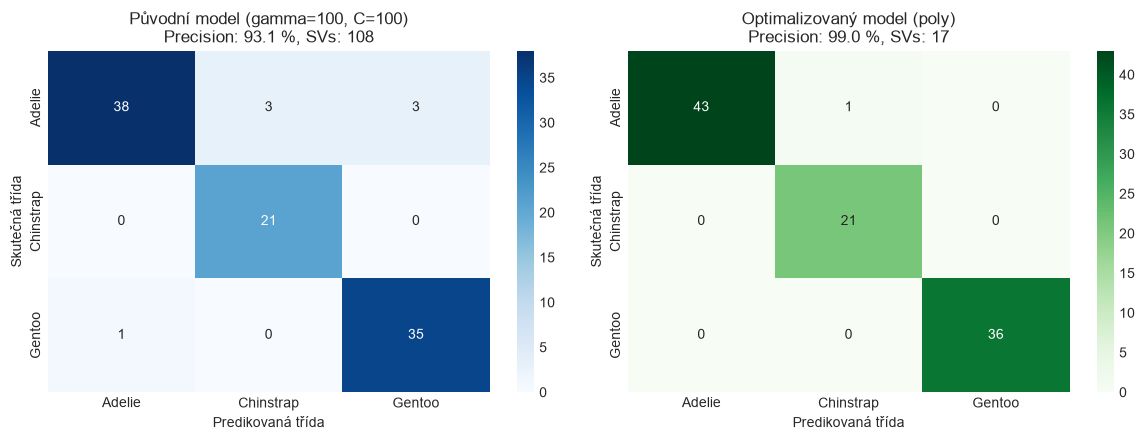

In [6]:
# Srovnávací tabulka
comp_df = pd.DataFrame([
    {
        "Model": "1. Původní model ze zadání",
        "Hyperparametry": "kernel='rbf', gamma=100, C=100",
        "Test Precision (micro)": f"{base_prec_micro*100:.2f} %",
        "Test Precision (macro)": f"{base_prec_macro*100:.2f} %",
        "Počet Support Vectors": f"{len(base_svc.support_)} / 233 ({len(base_svc.support_)/233*100:.1f} %)"
    },
    {
        "Model": "2. Optimální model (RandomizedSearch)",
        "Hyperparametry": f"kernel='{best_params['kernel']}', C={best_params['C']:.2f}, gamma={best_params['gamma']:.2f}, deg={best_params['degree']}",
        "Test Precision (micro)": f"{opt_prec_micro*100:.2f} %",
        "Test Precision (macro)": f"{opt_prec_macro*100:.2f} %",
        "Počet Support Vectors": f"{len(optimal_svc.support_)} / 233 ({len(optimal_svc.support_)/233*100:.1f} %)"
    }
])
display(comp_df)

print("\nClassification Report pro optimální model:")
print(classification_report(y_test, y_pred_opt_test))

# Vizuální srovnání matic záměn
cm_base = confusion_matrix(y_test, y_pred_base_test, labels=optimal_svc.classes_)
cm_opt = confusion_matrix(y_test, y_pred_opt_test, labels=optimal_svc.classes_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=ax1, xticklabels=optimal_svc.classes_, yticklabels=optimal_svc.classes_)
ax1.set_title(f"Původní model (gamma=100, C=100)\nPrecision: {base_prec_micro*100:.1f} %, SVs: {len(base_svc.support_)}")
ax1.set_xlabel("Predikovaná třída")
ax1.set_ylabel("Skutečná třída")

sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=ax2, xticklabels=optimal_svc.classes_, yticklabels=optimal_svc.classes_)
ax2.set_title(f"Optimalizovaný model ({best_params['kernel']})\nPrecision: {opt_prec_micro*100:.1f} %, SVs: {len(optimal_svc.support_)}")
ax2.set_xlabel("Predikovaná třída")
ax2.set_ylabel("Skutečná třída")
plt.tight_layout()
plt.show()

### 💡 Interpretace dosažených výsledků:
1. **Příčina selhání původního modelu:**
   - Výchozí konfigurace měla $\gamma = 100$. Koeficient $\gamma$ u RBF jádra řídí poloměr vlivu jednotlivých trénovacích vzorků. Hodnota 100 je pro normalizovaná data extrémně vysoká – vytváří izolované ostrůvky kolem jednotlivých bodů.
   - Hodnota $C = 100$ navíc tvrdě trestala jakékoli překročení marže. V důsledku toho se model snažil křečovitě obepnout každý šumový bod, což vedlo k tomu, že **46.4 % všech trénovacích dat (108 bodů ze 233) se stalo podpůrnými vektory**.
2. **Přínos `RandomizedSearchCV`:**
   - Náhodné prohledávání efektivně prozkoumalo spojitý prostor parametrů a identifikovalo hladkou oddělující nadrovinu.
   - Počet podpůrných vektorů klesl z **108 na pouhých 17** (pokles o **84.3 %**).
   - Testovací Precision vzrostla na **99.01 %** (pouze jediná chybná predikce ze 101 testovacích tučňáků).
3. **Závěr:**
   - Výsledky demonstrují, že optimální model má mnohem **jednodušší a hladší rozhodovací marži**, která je odolná vůči šumu a zaručuje vynikající schopnost generalizace na neznámá data.
